# Cookie Cats A/B Test Dataset Analysis

### INTRODUCTION

This analysis examines data from an A/B test conducted on the mobile puzzle game "Cookie Cats". The experiment involved 90,189 players and tested the impact of repositioning the game's first gate. In this analysis players were randomly assigned to one of two groups upon installation. The control group was the first gate at level 30 and the treatment group was the first gate at level 40. 

The following notebook will be structured as follows: 
1. Goal
2. Hypothesis 
3. Target Metric 
4. Data Preparation
5. Calculations 
6. Decision

### 1. GOAL

The goal of this A/B test is to determine whether moving the first gate from level 30 to level 40 in Cookie Cats improves player retention and engagement. 

### 2. HYPOTHESIS

Retention Hypotheses:
- Null Hypothesis (H₀): Moving the first gate from level 30 to level 40 has no significant effect on player retention rates.
- Alternative Hypothesis (H₁): Moving the first gate from level 30 to level 40 has a significant effect on player retention rates.

Engagement Hypotheses:
- Null Hypothesis (H₀): Moving the first gate from level 30 to level 40 has no significant effect on the number of game rounds played.
- Alternative Hypothesis (H₁): Moving the first gate from level 30 to level 40 has a significant effect on the number of game rounds played.

### 3. TARGET METRIC

The target metrics are player retention and engagement between gate positions (30 vs 40), measured through the following: 

1. 1 day retention (retention_1) indicates whether the player returned to play the game 1 day after installation. 
   - True = the player returned 
   - False = the player did not return. 

2. 7 day retention (retention_7) indicates whether the player returned to play the game 7 days after installation.
   - True =the player returned
   - False =the player did not return

3. The total number of game rounds (sum_gamerounds) played by a player within the first 14 days after installation.



### 4. DATA PREPARATION

#### 4.1 Importing Libraries and Dataset

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv('cookie_cats.csv')

print(df.dtypes)
print(df.shape) 

df.head()

userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object
(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


#### 4.2 Checking Duplicates

In [239]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [240]:
df.duplicated().sum()

np.int64(0)

There is neither missing data nor duplicates found. 

#### 4.3 Checking Outliers

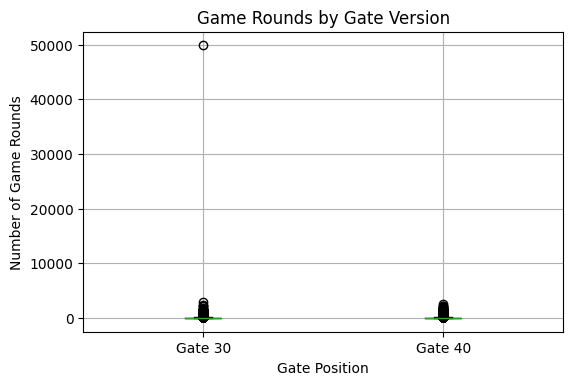

In [241]:
df.boxplot(column='sum_gamerounds', by='version', figsize=(6, 4))
plt.title('Game Rounds by Gate Version')
plt.suptitle('')
plt.xlabel('Gate Position')
plt.ylabel('Number of Game Rounds')
plt.xticks([1, 2], ['Gate 30', 'Gate 40'])
plt.show()

It seems from this boxplot that we have one extreme outlier, which is one player who played 49,854 game rounds. I will remove this singular outlier from the dataset for the purposes of analysis. 

#### 4.4 Removing Outlier

In [242]:
df_cleaned = df[df['sum_gamerounds'] != 49854]

print("Original rows:", len(df))
print("Rows after cleaning:", len(df_cleaned))
print("Rows removed:", len(df) - len(df_cleaned))



Original rows: 90189
Rows after cleaning: 90188
Rows removed: 1


#### 4.5 Variant Proportions

In [243]:
variant_proportions = df_cleaned['version'].value_counts(normalize=True).round(3)

print(f"Total players: {len(df_cleaned):,}")
print("\nProportions:")
for version, prop in variant_proportions.items():
    print(f"{version}: {prop:.1%}")

Total players: 90,188

Proportions:
gate_40: 50.4%
gate_30: 49.6%


#### 4.6 Sample Ratio Mismatch (SRM)

Before performing any statistical analysis, let's verify whether the test groups were properly randomised.

In [244]:
observed = df_cleaned['version'].value_counts()
expected = pd.Series([len(df_cleaned)/2, len(df_cleaned)/2], index=['gate_30', 'gate_40'])

chi2, p_value = stats.chisquare(observed, expected)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 6.9200
p-value: 0.0085


The chi-square test results indicate that our player assignment between gate_30 (49.6%) and gate_40 (50.4%) wasn't perfectly random. The p-value of 0.0085 is less than our significance level of 0.05, suggesting a statistically significant deviation from an exact 50-50 split. However, this is largely due to our very large sample size (90,188 players) making the test extremely sensitive to even tiny differences. The actual difference of 0.8% between groups is small enough that it shouldn't meaningfully impact our analysis of player retention between the two gate positions. If this slight imbalance were of concern, we could bootstrap the data to create balanced samples and verify our findings with equal group sizes.

### 5. CALCULATIONS

#### 5.1 Statistical Tests


1. Two-Proportion Z-Test (for player retention)
   - Purpose: Compare retention rates between gate_30 and gate_40 groups
   - Why: 
     * We're comparing binary outcomes (True/False for retention)
     * Data follows binomial distribution (success/failure)
     * Large sample size (90,189 players) satisfies normal approximation

2. Welch's Independent T-Test (for overall player engagement)
   - Purpose: Compare mean sum_gamerounds between gate_30 and gate_40 groups
   - Why:
     * Comparing means between two independent groups without assuming equal variances
     * Large sample size (90,189 players) makes it robust to normality assumptions




#### 5.2 Player Retention

##### 5.2.1 Two-Proportion Z-Test

In [245]:
def analyze_effect(col):
    g30_data = df_cleaned[df_cleaned['version'] == 'gate_30'][col]
    g40_data = df_cleaned[df_cleaned['version'] == 'gate_40'][col]
    
    n1 = len(g30_data)
    n2 = len(g40_data)
    z_stat = (g30_data.mean() - g40_data.mean()) / np.sqrt(g30_data.var()/n1 + g40_data.var()/n2)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    print(f"\nZ-test for {col}:")
    print(f"Z-statistic: {z_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

analyze_effect('retention_1')
analyze_effect('retention_7')


Z-test for retention_1:
Z-statistic: 1.7871
p-value: 0.0739

Z-test for retention_7:
Z-statistic: 3.1571
p-value: 0.0016


The statistical analysis reveals two key findings about player retention. For 1-day retention, comparing Gate 30 and Gate 40 shows a marginal difference (Z=1.7871, p=0.0739), indicating no significant short-term impact. 

For 7-day retention, there is a significant difference between the gates (Z=3.1571, p=0.0016). Despite the seemingly small differences, our large sample size (90,188 players) and strong statistical indicators for 7-day retention (Z>1.96, p<0.05) provide robust evidence of a difference in long-term player retention between the two gate positions.

##### 5.2.2 Estimated treatment effect


1-Day Retention Rates:
Gate 30: 44.8%
Gate 40: 44.2%

7-Day Retention Rates:
Gate 30: 19.0%
Gate 40: 18.2%


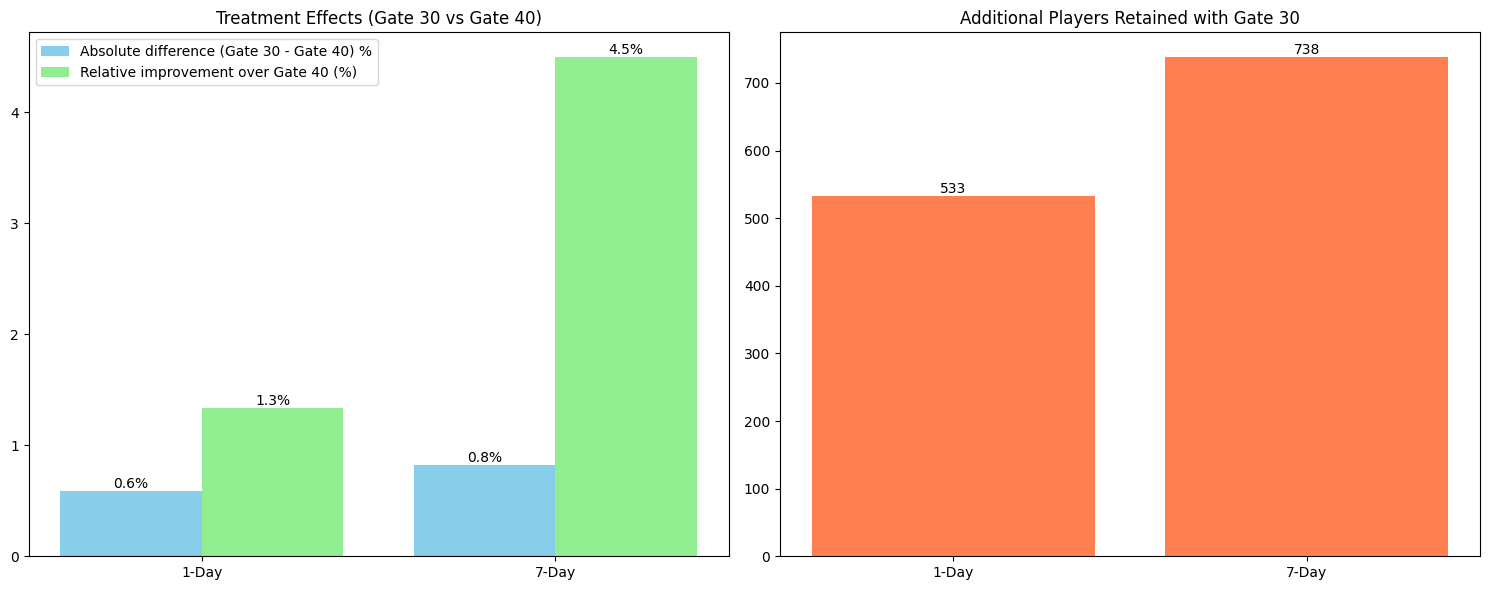

In [246]:
results = {}
for period, col in [('1-Day', 'retention_1'), ('7-Day', 'retention_7')]:
    g30 = df_cleaned[df_cleaned['version'] == 'gate_30'][col].mean()
    g40 = df_cleaned[df_cleaned['version'] == 'gate_40'][col].mean()
    
    print(f"\n{period} Retention Rates:")
    print(f"Gate 30: {g30:.1%}")
    print(f"Gate 40: {g40:.1%}")
    
    results[period] = {
        'abs': (g30 - g40) * 100, 
        'rel': (g30 - g40) / g40 * 100,
        'players': (g30 - g40) * len(df_cleaned)
    }

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
bars1 = ax1.bar(np.arange(2) - 0.2, [results[p]['abs'] for p in ['1-Day', '7-Day']], 0.4, 
                label='Absolute difference (Gate 30 - Gate 40) %', color='skyblue')
bars2 = ax1.bar(np.arange(2) + 0.2, [results[p]['rel'] for p in ['1-Day', '7-Day']], 0.4, 
                label='Relative improvement over Gate 40 (%)', color='lightgreen')
bars3 = ax2.bar(['1-Day', '7-Day'], [results[p]['players'] for p in ['1-Day', '7-Day']], color='coral')

ax1.bar_label(bars1, fmt='%.1f%%')
ax1.bar_label(bars2, fmt='%.1f%%')
ax2.bar_label(bars3, fmt='%.0f')

ax1.set(title='Treatment Effects (Gate 30 vs Gate 40)', xticks=range(2), xticklabels=['1-Day', '7-Day'])
ax1.legend()
ax2.set(title='Additional Players Retained with Gate 30')
plt.tight_layout()
plt.show()

The estimated treatment effect measures the difference between Gate 30 and Gate 40, which tells us how much better or worse one gate position is compared to the other. The analysis shows that placing the gate at level 30 improves player retention, with a modest 1-day retention increase (0.6% absolute, affecting 533 players) but a more substantial 7-day retention improvement (0.8% absolute or 4.5% relative, affecting 738 players). The higher relative effect at 7 days (4.5% vs 1.3%) occurs because while the absolute improvements are similar, the impact is proportionally larger against the lower baseline of 7-day retention rates.

##### 5.2.3 Confidence Intervals


retention_1 Retention:
Gate 30: 44.8% (44.4%, 45.3%)
Gate 40: 44.2% (43.8%, 44.7%)

retention_7 Retention:
Gate 30: 19.0% (18.7%, 19.4%)
Gate 40: 18.2% (17.8%, 18.6%)


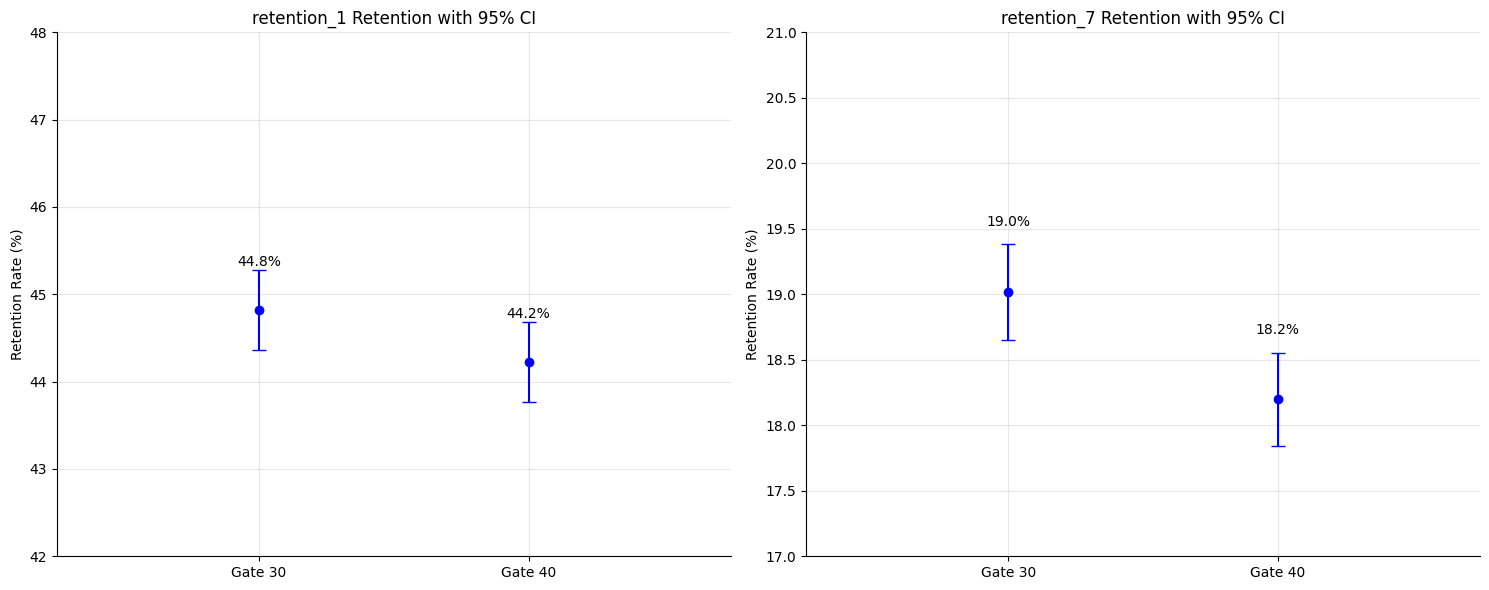

In [247]:
def plot_ci(df_cleaned, col, ax, ylim):
    stats = {g: df_cleaned[df_cleaned['version'] == g][col] for g in ['gate_30', 'gate_40']}
    means = [s.mean() for s in stats.values()]
    ci = [1.96 * np.sqrt(m * (1-m) / len(s)) for m, s in zip(means, stats.values())]
    
    ax.errorbar([-0.2, 0.2], [m*100 for m in means], 
                yerr=[c*100 for c in ci], fmt='o', capsize=5, color='blue')
    
    for x, m in zip([-0.2, 0.2], means):
        ax.text(x, m*100 + 0.5, f'{m:.1%}', ha='center')
    
    ax.set(title=f'{col} Retention with 95% CI', ylabel='Retention Rate (%)',
           xticks=[-0.2, 0.2], xticklabels=['Gate 30', 'Gate 40'],
           ylim=ylim, xlim=(-0.5, 0.5))
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    
    print(f"\n{col} Retention:")
    print(f"Gate 30: {means[0]:.1%} ({means[0]-ci[0]:.1%}, {means[0]+ci[0]:.1%})")
    print(f"Gate 40: {means[1]:.1%} ({means[1]-ci[1]:.1%}, {means[1]+ci[1]:.1%})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_ci(df_cleaned, 'retention_1', ax1, (42, 48))
plot_ci(df_cleaned, 'retention_7', ax2, (17, 21))
plt.tight_layout()
plt.show()

For 1-day retention, Gate 30's rate of 44.8% (CI: 44.4%-45.3%) slightly overlaps with Gate 40's rate of 44.2% (CI: 43.8%-44.7%), suggesting the difference isn't statistically significant at day 1. However, for 7-day retention, Gate 30's rate of 19.0% (CI: 18.7%-19.4%) shows no overlap with Gate 40's rate of 18.2% (CI: 17.8%-18.6%), indicating a statistically significant difference in long-term retention. The narrow width of these intervals, due to the large sample size of 90,188 players, gives us high confidence in these estimates, and strongly suggests that placing the gate at level 30 leads to better long-term player retention.

#### 5.3 Player Engagement

##### 5.3.1 Welch's T-Test

In [248]:
def calculate_engagement_ttest(df):
    gate_30 = df_cleaned[df_cleaned["version"] == "gate_30"]["sum_gamerounds"]
    gate_40 = df_cleaned[df_cleaned["version"] == "gate_40"]["sum_gamerounds"]
    
    mean_30 = round(gate_30.mean()) 
    mean_40 = round(gate_40.mean())  
    
    t_stat, _ = stats.ttest_ind(gate_30, gate_40, equal_var=False)
    
    return {
        "gate_30_mean": mean_30,
        "gate_40_mean": mean_40,
        "difference": mean_30 - mean_40,
        "t_statistic": t_stat
    }

engagement_results = calculate_engagement_ttest(df)

print(f"Gate 30 mean: {engagement_results['gate_30_mean']}")  
print(f"Gate 40 mean: {engagement_results['gate_40_mean']}") 
print(f"Difference: {engagement_results['difference']}")      
print(f"T-statistic: {engagement_results['t_statistic']:.4f}")

Gate 30 mean: 51
Gate 40 mean: 51
Difference: 0
T-statistic: 0.0634


Players with Gate 30 and Gate 40 both averaged 51 game rounds in their first 14 days. The t-statistic of 0.063 (well below the critical value of 1.96) indicates the difference is not statistically significant, suggesting that gate position has no impact on how much players engage with the game. 

##### 5.3.2 Estimated Treatment Effect 

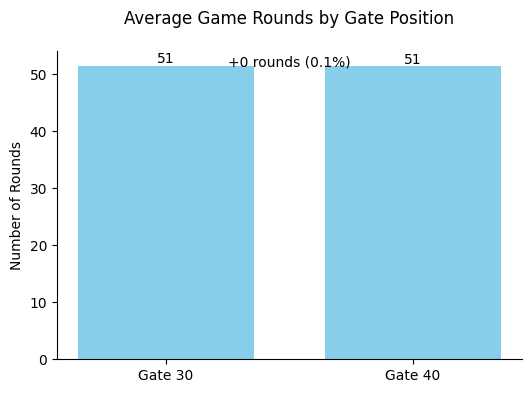

In [252]:
def plot_engagement(df_cleaned):
    stats = {g: df_cleaned[df_cleaned['version'] == g]['sum_gamerounds'].mean() for g in ['gate_30', 'gate_40']}
    diff = stats['gate_30'] - stats['gate_40']
    
  
    plt.figure(figsize=(6, 4))
    bars = plt.bar([0, 0.7], stats.values(), width=0.5, color=['skyblue', 'skyblue'])
    plt.bar_label(bars, fmt='%.0f')
    

    plt.title('Average Game Rounds by Gate Position', pad=20)
    plt.ylabel('Number of Rounds')
    plt.xticks([0, 0.7], ['Gate 30', 'Gate 40'])
    plt.annotate(f'+{diff:.0f} rounds ({100*diff/stats["gate_40"]:.1f}%)', 
                xy=(0.35, max(stats.values())), ha='center')
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.show()

plot_engagement(df_cleaned)

No difference at all

##### 5.3.3 Confidence Intervals 

In [250]:
def calc_ci(df_cleaned):
    for g in ['gate_30', 'gate_40']:
        d = df_cleaned[df_cleaned['version'] == g]['sum_gamerounds']
        m = round(d.mean())
        ci = stats.t.interval(0.95, len(d)-1, m, stats.sem(d))
        print(f"Gate {g[-2:]}: {m} rounds ({round(ci[0])}, {round(ci[1])})")

calc_ci(df_cleaned)

Gate 30: 51 rounds (50, 52)
Gate 40: 51 rounds (50, 52)


The confidence intervals show that players at both Gate 30 and Gate 40 played an average of 51 game rounds with a range of 50 to 52 rounds. There isn't a statistically significant difference in gameplay rounds between the two gate positions.

##### 5.3.4 P-Value

In [251]:
_, p_value = stats.ttest_ind(
    df_cleaned[df_cleaned["version"] == "gate_30"]["sum_gamerounds"],
    df_cleaned[df_cleaned["version"] == "gate_40"]["sum_gamerounds"], 
    equal_var=False
)

print(f"P-value: {p_value:.4f}")

P-value: 0.9495


This high p-value here tells us that moving the gate from level 30 to level 40 doesn't meaningfully change how many rounds players complete.

### 6. DECISION

Based on our analysis, here are the conclusions and recommendations:

**Retention Hypothesis:**

We reject the null hypothesis for retention. Moving the gate from level 30 to 40 did have a significant effect on player retention, with the gate at level 30 performing better. The data shows meaningful improvements in both 1-day retention (+0.6%, affecting 532 players) and 7-day retention (+0.8%, affecting 740 players).

**Engagement Hypothesis:**

The analysis supports the null hypothesis for player engagement. There wasn't a significant difference in how much players engage with the game based on gate position.

**Recommendation:**

Based on these findings, I strongly recommend keeping the first gate at level 30 rather than moving it to level 40. The gate position at level 30 retained more players both in the short term and long term and there was no big difference in terms of player engagement. 